In [4]:
# ----------------------------------------
# Intelligent Resume Screening System ---> By Sidharth
# ----------------------------------------

In [1]:
pip install pandas scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# Loading Dataset
data = pd.read_csv("Resume.csv")

print("Dataset is Loading...\n")
print(data.head())
print(data.columns)
print("\nDataset Loaded Successfully")


Dataset is Loading...

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Dataset Loaded Successfully


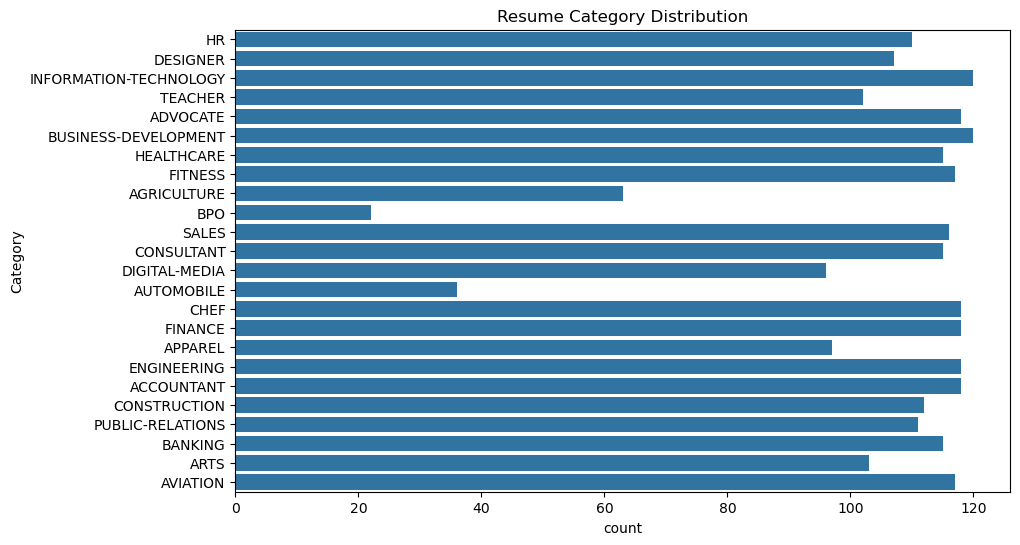

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(y=data["Category"])

plt.title("Resume Category Distribution")

plt.show()

In [6]:
# Extracting Resume Text

resumes = data['Resume_str'].astype(str)



In [7]:
# Using Text Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [word for word in tokens if word not in string.punctuation]

    return " ".join(tokens)



In [8]:
# Applying preprocessing to resumes
processed_resumes = resumes.apply(preprocess_text)



In [9]:
# Job Description:
job_description = "python , machine learning , data science , data analysis , pandas , numpy , scikit-learn , data visualization"

processed_job = preprocess_text(job_description)




In [10]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(processed_resumes)

job_vector = vectorizer.transform([processed_job])


In [11]:
# Calculating Similarity:

similarity_scores = cosine_similarity(job_vector, tfidf_matrix)



In [12]:
# Ranking Resumes:
scores = similarity_scores.flatten()

ranking = pd.DataFrame({
    "Resume_ID": data["ID"],
    "Score": scores
})

ranking = ranking.sort_values(by="Score", ascending=False)

ranking.index.name = "Index"


In [ ]:
# Show Top Resumes:

n = int(input("How many Top Resumes you want: \n"))
print("Top",n," Matching Resumes:")
print("For --> python , machine learning , data science , data analysis , pandas , numpy , scikit-learn , data visualization: \n")
# print(ranking.head(n))
ranking.head(n)